In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from mlxtend.frequent_patterns import fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder
import warnings
from IPython.display import display, Markdown

# --- Setup & Optimization ---
warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=UserWarning, module='mlxtend')
plt.style.use('seaborn-v0_8-muted')
sns.set_theme(style="whitegrid")

def optimize_types(df):
    for col in df.columns:
        if df[col].dtype == 'int64': df[col] = df[col].astype('int32')
        elif df[col].dtype == 'float64': df[col] = df[col].astype('float32')
    return df

# --- Data Loading & Preprocessing ---
def load_and_prep_data():
    products = pd.read_csv('products.csv')
    aisles = pd.read_csv('aisles.csv')
    departments = pd.read_csv('departments.csv')
    order_products = pd.read_csv('order_products__prior.csv', nrows = 2e7)
    orders = pd.read_csv('orders.csv')[['order_id', 'order_dow', 'order_hour_of_day']]

    # Merging
    df = order_products.merge(products, on='product_id', how='left')
    df = df.merge(aisles, on='aisle_id', how='left')
    df = df.merge(departments, on='department_id', how='left')
    df = df.merge(orders, on='order_id', how='left')

    # Dimensional Engineering
    bins = [0, 6, 12, 18, 24]
    labels = ['Night', 'Morning', 'Afternoon', 'Evening']
    df['hour_bin'] = 'Hour_' + pd.cut(df['order_hour_of_day'], bins=bins, labels=labels, right=False).astype(str)
    df['day_type'] = df['order_dow'].apply(lambda x: 'Weekend' if x in [0, 1] else 'Weekday')
    
    basket_counts = df.groupby('order_id')['product_id'].transform('count')
    df['basket_size'] = pd.cut(basket_counts, bins=[0, 5, 15, 100], labels=['Small_Basket', 'Medium_Basket', 'Large_Basket'])
    
    return optimize_types(df)

# --- Core Mining Utilities ---
def get_basket(df, level_column):
    """Prepares sparse TransactionEncoder dataframe."""
    df = df.dropna(subset=[level_column, 'hour_bin', 'day_type', 'basket_size'])
    baskets = df.groupby('order_id')[level_column].unique().reset_index()
    meta = df.drop_duplicates('order_id')[['order_id', 'hour_bin', 'day_type', 'basket_size']]
    merged = baskets.merge(meta, on='order_id')
    
    transaction_list = [list(items) + list(meta) for items, meta in zip(merged[level_column], merged[['hour_bin', 'day_type', 'basket_size']].values)]
    
    te = TransactionEncoder()
    te_ary = te.fit(transaction_list).transform(transaction_list, sparse=True)
    return pd.DataFrame.sparse.from_spmatrix(te_ary, columns=te.columns_)

def enhance_rules(rules_df, level_type):
    """Calculates Kulc/IR and applies your specific level thresholds."""
    if rules_df.empty: return rules_df
    
    # Formulas: Kulczynski & Imbalance Ratio
    rules_df['kulczynski'] = (rules_df['support']/rules_df['antecedent support'] + rules_df['support']/rules_df['consequent support']) / 2
    rules_df['ir'] = np.abs(rules_df['antecedent support'] - rules_df['consequent support']) / (rules_df['antecedent support'] + rules_df['consequent support'] - rules_df['support'])
    
    # Threshold Logic
    if level_type == 'product_name':
        rules_df['is_robust'] = (rules_df['kulczynski'] > 0.3) & (rules_df['ir'] < 0.7)
    else: # Aisle or Department
        rules_df['is_robust'] = (rules_df['kulczynski'] > 0.5) & (rules_df['ir'] < 0.5)
    
    rules_df['ant_str'] = rules_df['antecedents'].apply(lambda x: ', '.join(list(x)))
    rules_df['cons_str'] = rules_df['consequents'].apply(lambda x: ', '.join(list(x)))
    return rules_df

def filter_redundancy(low_rules, high_rules, mapping):
    """Removes low-level rules that are already explained by a high-level rule."""
    if low_rules.empty or high_rules is None or high_rules.empty: return low_rules
    
    high_set = set((tuple(sorted(list(a))), tuple(sorted(list(c)))) for a, c in zip(high_rules['antecedents'], high_rules['consequents']))

    def check_redundancy(row):
        ant_high = tuple(sorted(set(mapping.get(item, item) for item in row['antecedents'])))
        cons_high = tuple(sorted(set(mapping.get(item, item) for item in row['consequents'])))
        return (ant_high, cons_high) in high_set

    return low_rules[~low_rules.apply(check_redundancy, axis=1)]

# --- Visualization ---
def plot_robustness(rules_df, title):
    if rules_df.empty: return
    plt.figure(figsize=(10, 5))
    sns.scatterplot(data=rules_df, x='kulczynski', y='ir', size='lift', hue='is_robust', palette={True: 'green', False: 'red'}, alpha=0.6)
    plt.title(f"Robustness: {title}")
    plt.axvline(0.5, color='gray', linestyle='--')
    plt.show()

# --- Master Pipeline ---
def run_master_analysis(df):
    mapping_data = df[['product_name', 'aisle', 'department']].drop_duplicates()
    prod_to_aisle = mapping_data.set_index('product_name')['aisle'].to_dict()
    aisle_to_dept = mapping_data[['aisle', 'department']].drop_duplicates().set_index('aisle')['department'].to_dict()

    level_configs = [
        ('department', 0.1, None),
        ('aisle', 0.02, aisle_to_dept),
        ('product_name', 0.005, prod_to_aisle)
    ]
    
    results = {}

    for dim in ['Weekend', 'Weekday']:
        print(f"\n" + "█" * 60)
        print(f"  DIMENSION: {dim.upper()}")
        print("█" * 60)
        
        df_subset = df[df['day_type'] == dim]
        prev_rules = None
        
        for level, sup, mapping in level_configs:
            basket_df = get_basket(df_subset, level)
            freq_items = fpgrowth(basket_df, min_support=sup, use_colnames=True)
            rules = association_rules(freq_items, metric="lift", min_threshold=1.0)
            
            rules = enhance_rules(rules, level)
            filtered_rules = filter_redundancy(rules, prev_rules, mapping)
            robust_count = filtered_rules['is_robust'].sum()
            print(f"\n--- LEVEL: {level.upper()} (Sup: {sup}) ---")
            print(f"Found: {len(rules):<6} | Unique: {len(filtered_rules):<6} | Robust: {robust_count}")
            if not filtered_rules.empty:
                plot_robustness(filtered_rules, f"{dim} - {level}")
                top = filtered_rules[filtered_rules['is_robust']].sort_values('lift', ascending=False)
                
                if not top.empty:
                    print(f"\n>>> Robust Rules (Sorted by Lift):")
                    with pd.option_context('display.max_colwidth', 60, 'display.width', 250):
                        print(top[['ant_str', 'cons_str', 'lift', 'kulczynski']].to_string(index=False))
            
            results[(dim, level)] = filtered_rules
            prev_rules = rules
            print("-" * 40)
    
    return results

In [2]:
def plot_rules_network(rules_df, title="Association Rules Network", num_rules=100):
    if rules_df.empty:
        print(f"No rules to plot for: {title}")
        return

    G = nx.DiGraph()
    top_rules = rules_df.sort_values('lift', ascending=False).head(num_rules)
    
    for _, row in top_rules.iterrows():
        ant = row['ant_str']
        cons = row['cons_str']
        G.add_edge(ant, cons, weight=row['lift'], supp=row['support'])

    plt.figure(figsize=(12, 8))
    pos = nx.spring_layout(G, k=1, seed=42)
    
    nx.draw_networkx_nodes(G, pos, node_size=2000, node_color="#a8dadc", alpha=0.9)
    nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold')
    
    edges = G.edges()
    weights = [G[u][v]['weight'] * 0.5 for u, v in edges]
    nx.draw_networkx_edges(G, pos, width=weights, edge_color='#457b9d', 
                           arrowsize=15, connectionstyle='arc3,rad=0.1')

    plt.title(f"{title}\n(Line thickness = Lift)", fontsize=14)
    plt.axis('off')
    plt.show()

In [3]:
def run_level_pipeline(df_subset, level, sup, mapping, prev_rules, dim_name):
    basket_df = get_basket(df_subset, level)
    freq_items = fpgrowth(basket_df, min_support=sup, use_colnames=True)
    rules = association_rules(freq_items, metric="lift", min_threshold=1.0)
    rules = enhance_rules(rules, level)
    filtered_rules = filter_redundancy(rules, prev_rules, mapping)
    
    display(Markdown(f"## {dim_name} - {level.upper()} Analysis"))
    print(f"Found: {len(rules)} | Unique: {len(filtered_rules)} | Robust: {filtered_rules['is_robust'].sum()}")
    
    if not filtered_rules.empty:
        plot_robustness(filtered_rules, f"{dim_name} - {level}")
        top = filtered_rules[filtered_rules['is_robust']].sort_values('lift', ascending=False)
        if not top.empty:
            display(Markdown(f"### Top Robust Rules"))
            display(top[['ant_str', 'cons_str', 'lift', 'kulczynski', 'ir']].head(25))
            plot_rules_network(top, title=f"Network: {dim_name} {level}")
            
    return rules

## main code

In [4]:

df_merged = load_and_prep_data()
#final_results = run_master_analysis(df_merged)
mapping_data = df_merged[['product_name', 'aisle', 'department']].drop_duplicates()
prod_to_aisle = mapping_data.set_index('product_name')['aisle'].to_dict()
aisle_to_dept = mapping_data[['aisle', 'department']].drop_duplicates().set_index('aisle')['department'].to_dict()
rules_store = {'Weekend': {}, 'Weekday': {}}

## Weekend - DEPARTMENT Analysis

Found: 3998 | Unique: 3998 | Robust: 308


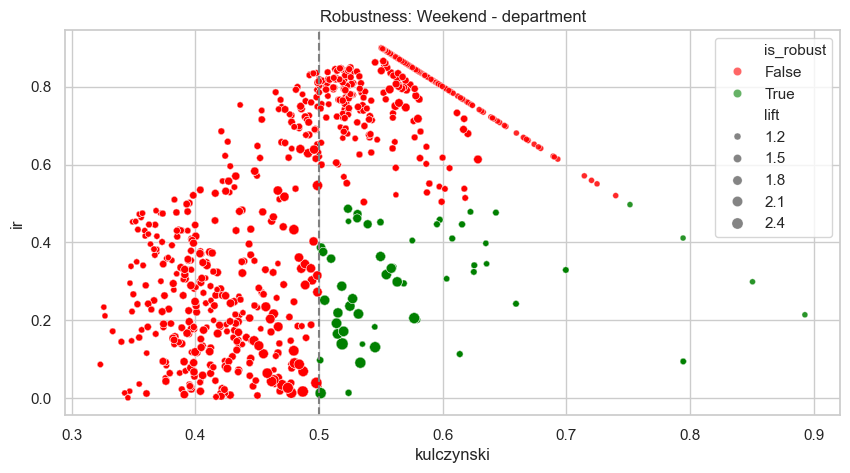

### Top Robust Rules

,ant_str,cons_str,lift,kulczynski,ir
3612,Large_Basket,"produce, snacks, frozen, Weekend",2.638199,0.518663,0.139411
3570,"produce, frozen, snacks",Large_Basket,2.638199,0.518663,0.139411
3583,Large_Basket,"produce, frozen, snacks",2.638199,0.518663,0.139411
3585,"produce, snacks, frozen, Weekend",Large_Basket,2.638199,0.518663,0.139411
3593,"produce, snacks, frozen","Large_Basket, Weekend",2.638199,0.518663,0.139411
3604,"Large_Basket, Weekend","produce, snacks, frozen",2.638199,0.518663,0.139411
3703,Large_Basket,"bakery, produce, dairy eggs, Weekend",2.332300,0.501249,0.012776
3673,Large_Basket,"bakery, produce, dairy eggs",2.332300,0.501249,0.012776
3692,"Large_Basket, Weekend","bakery, produce, dairy eggs",2.332300,0.501249,0.012776
3660,"bakery, produce, dairy eggs",Large_Basket,2.332300,0.501249,0.012776


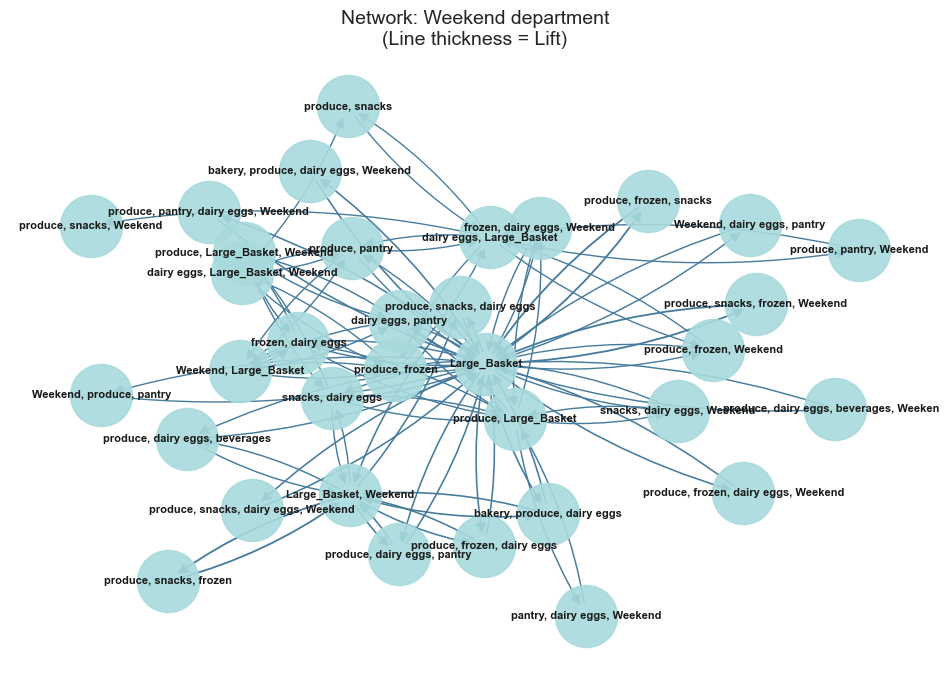

## Weekday - DEPARTMENT Analysis

Found: 2908 | Unique: 2908 | Robust: 216


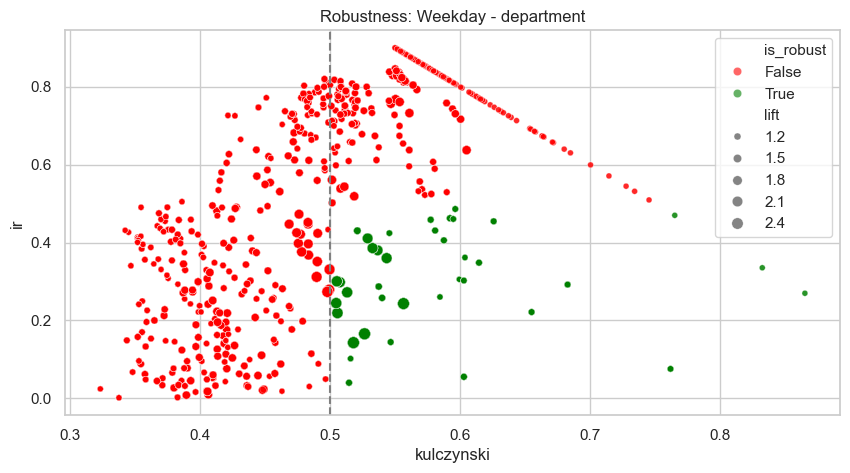

### Top Robust Rules

,ant_str,cons_str,lift,kulczynski,ir
2172,"produce, pantry, dairy eggs, Weekday",Large_Basket,2.557354,0.518176,0.143076
2154,"produce, dairy eggs, pantry",Large_Basket,2.557354,0.518176,0.143076
2180,"produce, dairy eggs, pantry","Weekday, Large_Basket",2.557354,0.518176,0.143076
2185,"Weekday, Large_Basket","produce, dairy eggs, pantry",2.557354,0.518176,0.143076
2193,Large_Basket,"produce, pantry, dairy eggs, Weekday",2.557354,0.518176,0.143076
2167,Large_Basket,"produce, dairy eggs, pantry",2.557354,0.518176,0.143076
2244,"produce, frozen, dairy eggs",Large_Basket,2.551897,0.526709,0.165782
2257,Large_Basket,"produce, frozen, dairy eggs",2.551897,0.526709,0.165782
2262,"produce, frozen, dairy eggs, Weekday",Large_Basket,2.551897,0.526709,0.165782
2270,"produce, frozen, dairy eggs","Weekday, Large_Basket",2.551897,0.526709,0.165782


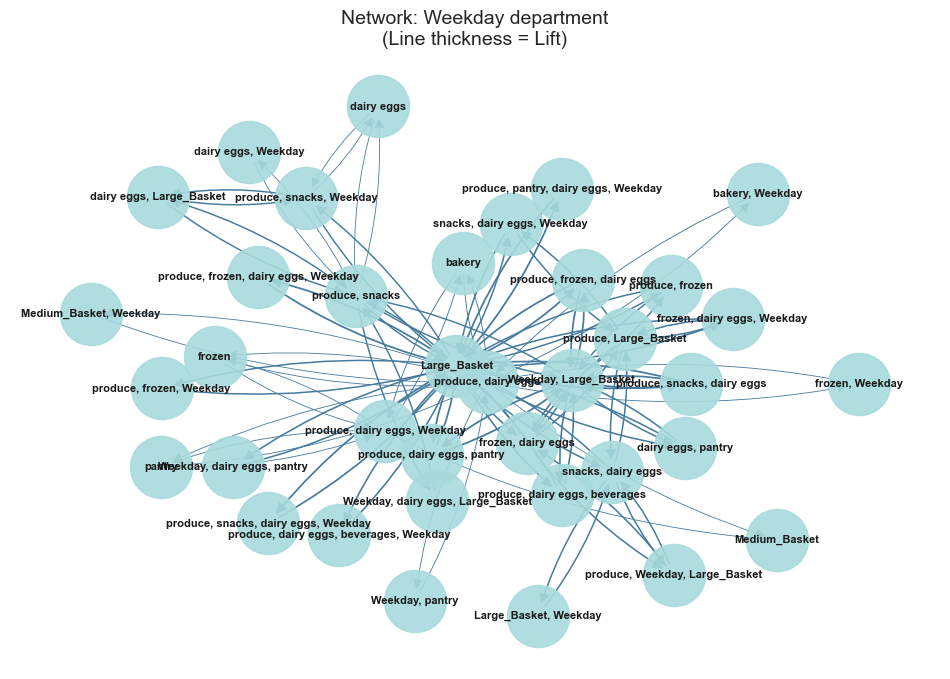

In [5]:
for dim in ['Weekend', 'Weekday']:
    df_subset = df_merged[df_merged['day_type'] == dim]
    rules_store[dim]['department'] = run_level_pipeline(
        df_subset, 
        level='department', 
        sup=0.1, 
        mapping=None,
        prev_rules=None,
        dim_name=dim
    )

## Weekend - AISLE Analysis

Found: 60988 | Unique: 34844 | Robust: 54


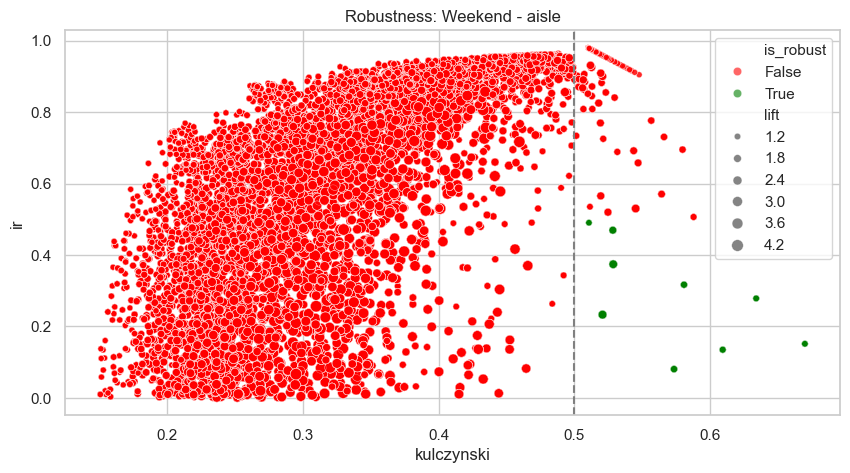

### Top Robust Rules

,ant_str,cons_str,lift,kulczynski,ir
44702,"fresh vegetables, packaged vegetables fruits","Large_Basket, fresh fruits",2.280125,0.520720,0.233027
44707,"Large_Basket, fresh fruits","fresh vegetables, packaged vegetables fruits",2.280125,0.520720,0.233027
44734,"Large_Basket, fresh fruits","fresh vegetables, packaged vegetables fruits, ...",2.280125,0.520720,0.233027
44733,"fresh vegetables, packaged vegetables fruits","Large_Basket, fresh fruits, Weekend",2.280125,0.520720,0.233027
44720,"Large_Basket, fresh fruits, Weekend","fresh vegetables, packaged vegetables fruits",2.280125,0.520720,0.233027
44719,"fresh vegetables, packaged vegetables fruits, ...","Large_Basket, fresh fruits",2.280125,0.520720,0.233027
44704,"fresh vegetables, Large_Basket","packaged vegetables fruits, fresh fruits",2.228747,0.528597,0.374220
44705,"packaged vegetables fruits, fresh fruits","fresh vegetables, Large_Basket",2.228747,0.528597,0.374220
44736,"fresh vegetables, Large_Basket","packaged vegetables fruits, fresh fruits, Weekend",2.228747,0.528597,0.374220
44717,"packaged vegetables fruits, fresh fruits, Weekend","fresh vegetables, Large_Basket",2.228747,0.528597,0.374220


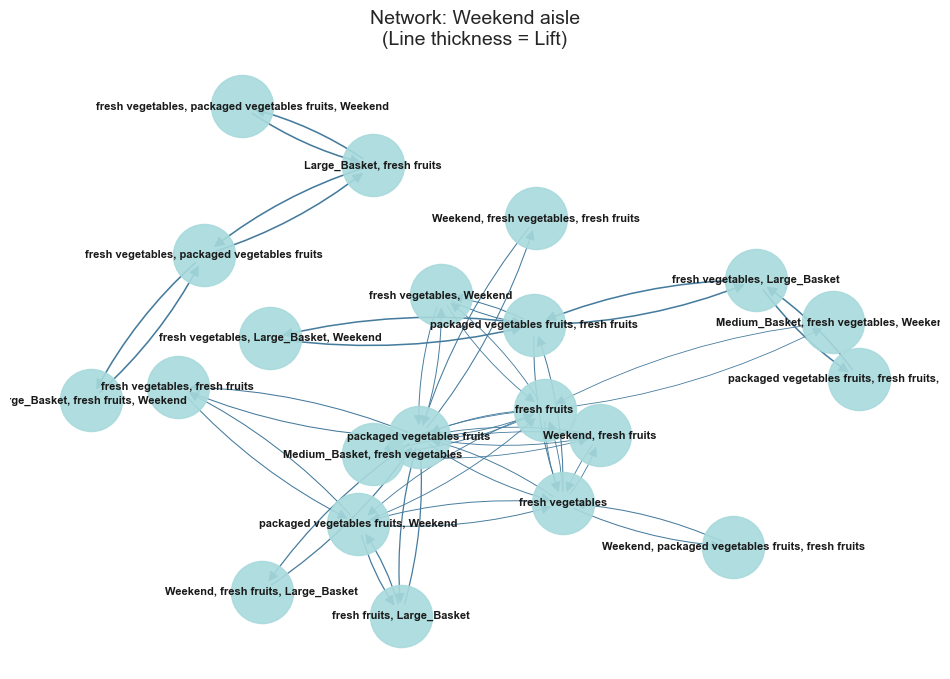

## Weekday - AISLE Analysis

Found: 33586 | Unique: 19278 | Robust: 36


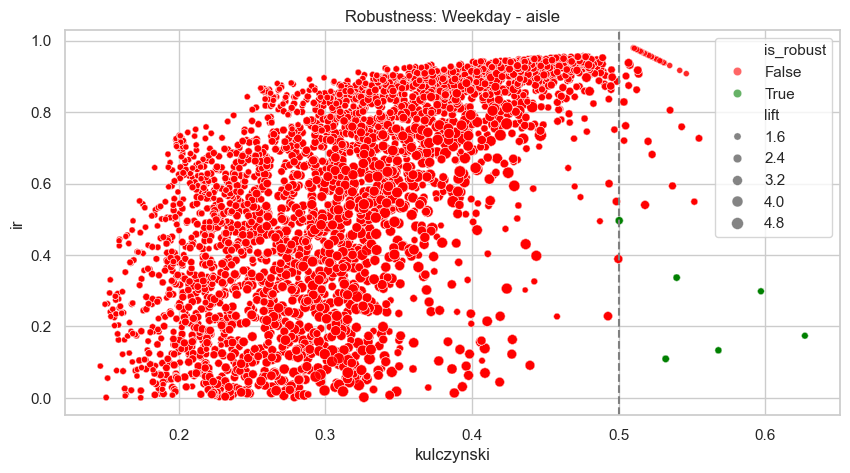

### Top Robust Rules

,ant_str,cons_str,lift,kulczynski,ir
13130,packaged vegetables fruits,"Weekday, fresh fruits, Large_Basket",2.000038,0.500445,0.496203
13127,"fresh fruits, Large_Basket","packaged vegetables fruits, Weekday",2.000038,0.500445,0.496203
13126,"packaged vegetables fruits, Weekday","fresh fruits, Large_Basket",2.000038,0.500445,0.496203
13123,"Weekday, fresh fruits, Large_Basket",packaged vegetables fruits,2.000038,0.500445,0.496203
13111,packaged vegetables fruits,"fresh fruits, Large_Basket",2.000038,0.500445,0.496203
13110,"fresh fruits, Large_Basket",packaged vegetables fruits,2.000038,0.500445,0.496203
149,"fresh vegetables, fresh fruits",packaged vegetables fruits,1.651764,0.532129,0.109290
165,packaged vegetables fruits,"fresh vegetables, Weekday, fresh fruits",1.651764,0.532129,0.109290
162,"packaged vegetables fruits, Weekday","fresh vegetables, fresh fruits",1.651764,0.532129,0.109290
159,"fresh vegetables, fresh fruits","packaged vegetables fruits, Weekday",1.651764,0.532129,0.109290


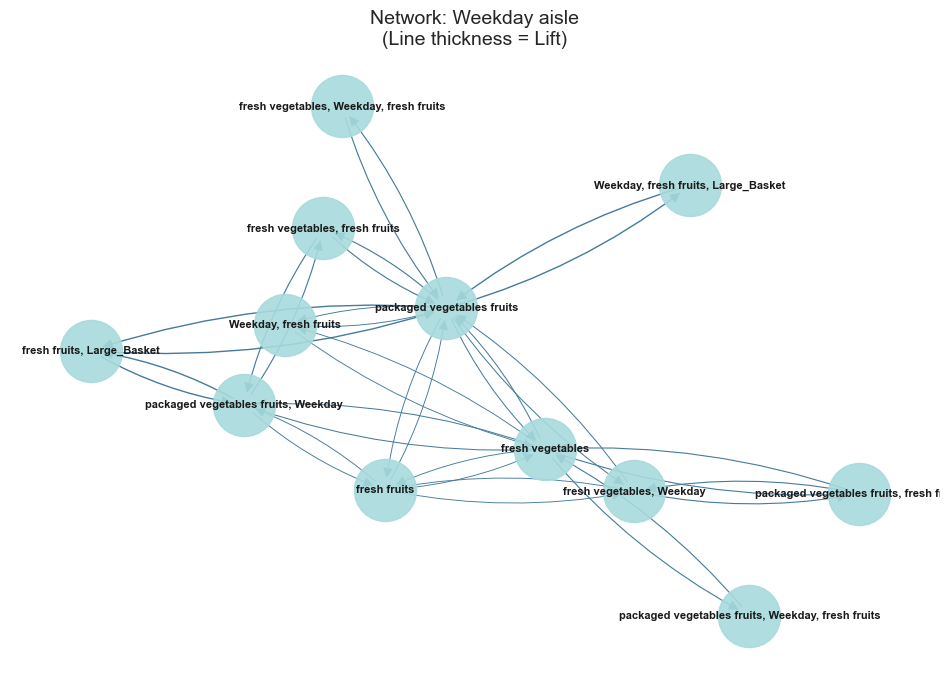

In [6]:
for dim in ['Weekend', 'Weekday']:
    df_subset = df_merged[df_merged['day_type'] == dim]
    rules_store[dim]['aisle'] = run_level_pipeline(
        df_subset, 
        level='aisle', 
        sup=0.02, 
        mapping=aisle_to_dept,
        prev_rules=rules_store[dim]['department'],
        dim_name=dim
    )

In [7]:
for dim in ['Weekend', 'Weekday']:
    df_subset = df_merged[df_merged['day_type'] == dim]
    rules_store[dim]['product_name'] = run_level_pipeline(
        df_subset,
        level='product_name',
        sup=0.005,
        mapping=prod_to_aisle,
        prev_rules=rules_store[dim]['aisle'],
        dim_name=dim
    )

MemoryError: Unable to allocate 30.1 GiB for an array with shape (47019, 687433) and data type bool

In [ ]:
for bin_name in ['Hour_Morning', 'Hour_Afternoon', 'Hour_Evening', 'Hour_Night']:
    rules_store[bin_name] = {}

In [ ]:
for bin_name in ['Hour_Morning', 'Hour_Afternoon', 'Hour_Evening', 'Hour_Night']:
    df_subset = df_merged[df_merged['hour_bin'] == bin_name]
    rules_store[bin_name]['department'] = run_level_pipeline(
        df_subset, 
        level='department', 
        sup=0.1, 
        mapping=None,
        prev_rules=None,
        dim_name=bin_name
    )

In [ ]:
"""
for bin_name in ['Hour_Morning', 'Hour_Afternoon', 'Hour_Evening', 'Hour_Night']:
    df_subset = df_merged[df_merged['hour_bin'] == bin_name]
    
    rules_store[bin_name]['aisle'] = run_level_pipeline(
        df_subset, 
        level='aisle', 
        sup=0.02, 
        mapping=aisle_to_dept, 
        prev_rules=rules_store[bin_name]['department'],
        dim_name=bin_name
    )

for bin_name in ['Hour_Morning', 'Hour_Afternoon', 'Hour_Evening', 'Hour_Night']:
    df_subset = df_merged[df_merged['hour_bin'] == bin_name]
    
    rules_store[bin_name]['product_name'] = run_level_pipeline(
        df_subset, 
        level='product_name', 
        sup=0.005, 
        mapping=prod_to_aisle, 
        prev_rules=rules_store[bin_name]['aisle'],
        dim_name=bin_name
    )
"""